# 06 — Recall@K and NDCG@K

**input:** `data/results_ours.pkl`, `data/results_random.pkl`, `data/results_taxonomy.pkl`

**metrics:**
- **Recall@K** — is the target in the final top-K items?
- **NDCG@K** — how highly is the target ranked in the final ranking?

For the final ranking: candidate set items are sorted by
cosine similarity with the query.

In [1]:
import numpy as np
import pandas as pd
import pickle, sys
from pathlib import Path
from sentence_transformers import SentenceTransformer

sys.path.append(str(Path('../')))
from query_templates import get_query_for_movie

DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')

movies     = pd.read_pickle(DATA_DIR / 'movies.pkl')
embeddings = np.load(DATA_DIR / 'embeddings.npy')
sbert      = SentenceTransformer('all-MiniLM-L6-v2')

with open(DATA_DIR / 'results_ours.pkl', 'rb') as f:
    ours = pickle.load(f)
with open(DATA_DIR / 'results_random.pkl', 'rb') as f:
    rand = pickle.load(f)
with open(DATA_DIR / 'results_taxonomy.pkl', 'rb') as f:
    taxo = pickle.load(f)

df_ours     = ours['df']
df_random   = rand['df']
df_taxonomy = taxo['df']
target_items = ours['target_items']

print(f'Loaded {len(target_items)} targets')
print('imports OK')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 200 targets
imports OK


### Part 1 — Ranking within the final candidate set

In [2]:
def rank_candidates(candidate_indices: list[int],
                    target_idx: int,
                    query_embedding: np.ndarray,
                    all_embeddings: np.ndarray) -> int:
    """
    Ranks candidate set items by cosine similarity with the query.
    Returns the rank of the target (1-indexed).
    If target is not in the candidate set, rank = len+1 (worst case).
    """
    if not candidate_indices:
        return len(all_embeddings) + 1

    embs   = all_embeddings[candidate_indices]
    scores = embs @ query_embedding
    ranked = np.argsort(scores)[::-1]
    ranked_indices = [candidate_indices[i] for i in ranked]

    if target_idx in ranked_indices:
        return ranked_indices.index(target_idx) + 1  # 1-indexed
    return len(ranked_indices) + 1


def recall_at_k(ranks: list[int], k: int) -> float:
    """Fraction of targets found in top-K."""
    return np.mean([1 if r <= k else 0 for r in ranks])


def ndcg_at_k(ranks: list[int], k: int) -> float:
    """
    NDCG@K — measures how highly the target is ranked.
    NDCG=1 if rank=1, decreases as rank worsens.
    """
    scores = []
    for r in ranks:
        if r <= k:
            scores.append(1.0 / np.log2(r + 1))
        else:
            scores.append(0.0)
    # normalize against ideal (rank=1)
    ideal = 1.0 / np.log2(2)  # rank=1
    return np.mean(scores) / ideal


print('metric functions defined')

metric functions defined


### Part 2 — compute ranks for each method

In [3]:
# for each target, build the query embedding
# then compute the target's rank in the final candidate set

# note: current results only store final_size and entropy_trace
# we need to re-run the interaction to recover the final candidate set

from sklearn.cluster import KMeans

def adaptive_k(n):
    if n <= 10:  return 2
    if n <= 30:  return 3
    if n <= 100: return 4
    return 5

def cluster_candidates(candidate_indices, all_embeddings, k):
    k = min(k, len(candidate_indices))
    if k == 1:
        return [candidate_indices]
    embs   = all_embeddings[candidate_indices]
    km     = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(embs)
    partition = [[] for _ in range(k)]
    for idx, lbl in zip(candidate_indices, labels):
        partition[lbl].append(idx)
    return [p for p in partition if p]

def simulated_user(partition, target_idx):
    for i, group in enumerate(partition):
        if target_idx in group:
            return i
    return 0

def random_partition(candidate_indices, k):
    shuffled = candidate_indices.copy()
    np.random.shuffle(shuffled)
    return [list(c) for c in np.array_split(shuffled, k) if len(c) > 0]

movie_primary_genre = movies['genres'].str.split('|').str[0].values
def taxonomy_partition(candidate_indices):
    groups = {}
    for idx in candidate_indices:
        g = movie_primary_genre[idx]
        groups.setdefault(g, []).append(idx)
    partition = [g for g in groups.values() if g]
    if len(partition) > 6:
        partition = sorted(partition, key=len, reverse=True)[:6]
    return partition

print('interaction functions ready')

interaction functions ready


In [4]:
from tqdm import tqdm

STOP_SIZE = 5
MAX_TURNS = 6
TOP_N     = 500

def run_and_rank(target_idx, method='ours'):
    """
    Runs the interaction and returns the target's rank in the final candidate set.
    """
    genres    = movies.iloc[target_idx]['genres']
    q_text    = get_query_for_movie(genres)
    q_emb     = sbert.encode(q_text, normalize_embeddings=True)

    # retrieval
    scores = embeddings @ q_emb
    C = np.argsort(scores)[::-1][:TOP_N].tolist()
    if target_idx not in C:
        C.append(target_idx)

    turn = 0
    while len(C) > STOP_SIZE and turn < MAX_TURNS:
        if method == 'ours':
            k = adaptive_k(len(C))
            partition = cluster_candidates(C, embeddings, k)
        elif method == 'random':
            k = adaptive_k(len(C))
            partition = random_partition(C, k)
        elif method == 'taxonomy':
            partition = taxonomy_partition(C)
            if len(partition) <= 1:
                break
        chosen = simulated_user(partition, target_idx)
        C = partition[chosen]
        turn += 1

    rank = rank_candidates(C, target_idx, q_emb, embeddings)
    return rank, len(C), q_emb


# run for all targets
np.random.seed(42)
ranks_ours, ranks_random, ranks_taxonomy = [], [], []

for t in tqdm(target_items, desc='Computing ranks'):
    r_our,  _, _ = run_and_rank(int(t), 'ours')
    r_ran,  _, _ = run_and_rank(int(t), 'random')
    r_tax,  _, _ = run_and_rank(int(t), 'taxonomy')
    ranks_ours.append(r_our)
    ranks_random.append(r_ran)
    ranks_taxonomy.append(r_tax)

print('Done.')

Computing ranks: 100%|██████████| 200/200 [00:22<00:00,  9.03it/s]

Done.


### Part 3 — Results

── Recall@K ─────────────────────────────────────────
   K    Semantic    Taxonomy      Random
----------------------------------------
   1       0.270       0.010       0.120
   3       0.620       0.015       0.310
   5       0.970       0.035       1.000
  10       1.000       0.045       1.000

── NDCG@K ───────────────────────────────────────────
   K    Semantic    Taxonomy      Random
----------------------------------------
   1       0.270       0.010       0.120
   3       0.464       0.013       0.225
   5       0.607       0.022       0.518
  10       0.617       0.025       0.518


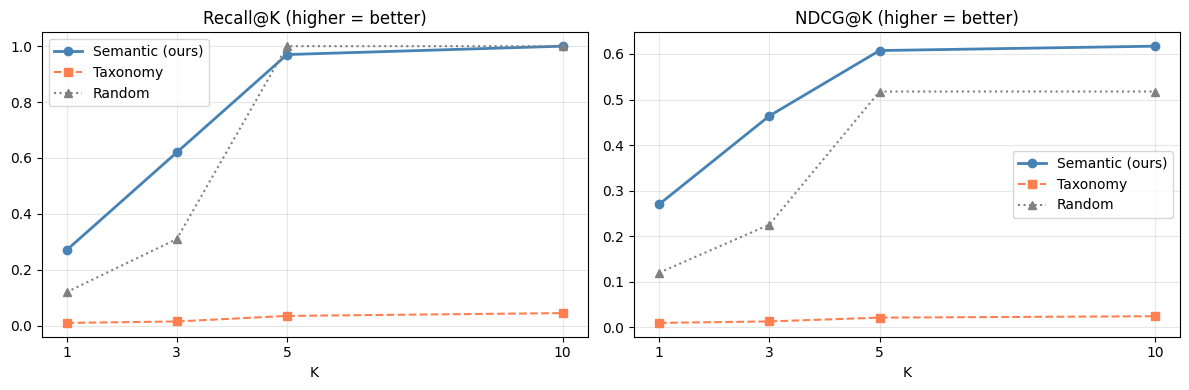

Saved: results/recall_ndcg.png

✅ notebook 06 complete


In [5]:
import matplotlib.pyplot as plt

ks = [1, 3, 5, 10]

print('── Recall@K ─────────────────────────────────────────')
print(f'{"K":>4}  {"Semantic":>10}  {"Taxonomy":>10}  {"Random":>10}')
print('-' * 40)
for k in ks:
    r_our = recall_at_k(ranks_ours, k)
    r_tax = recall_at_k(ranks_taxonomy, k)
    r_ran = recall_at_k(ranks_random, k)
    print(f'{k:>4}  {r_our:>10.3f}  {r_tax:>10.3f}  {r_ran:>10.3f}')

print()
print('── NDCG@K ───────────────────────────────────────────')
print(f'{"K":>4}  {"Semantic":>10}  {"Taxonomy":>10}  {"Random":>10}')
print('-' * 40)
for k in ks:
    n_our = ndcg_at_k(ranks_ours, k)
    n_tax = ndcg_at_k(ranks_taxonomy, k)
    n_ran = ndcg_at_k(ranks_random, k)
    print(f'{k:>4}  {n_our:>10.3f}  {n_tax:>10.3f}  {n_ran:>10.3f}')

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric_fn, title in [
    (axes[0], recall_at_k, 'Recall@K'),
    (axes[1], ndcg_at_k,   'NDCG@K'),
]:
    our_vals  = [metric_fn(ranks_ours,     k) for k in ks]
    tax_vals  = [metric_fn(ranks_taxonomy, k) for k in ks]
    ran_vals  = [metric_fn(ranks_random,   k) for k in ks]

    ax.plot(ks, our_vals, marker='o', color='steelblue', label='Semantic (ours)', linewidth=2)
    ax.plot(ks, tax_vals, marker='s', color='coral',     label='Taxonomy', linestyle='--')
    ax.plot(ks, ran_vals, marker='^', color='gray',      label='Random',   linestyle=':')
    ax.set_xlabel('K')
    ax.set_title(f'{title} (higher = better)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(ks)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'recall_ndcg.png', dpi=150)
plt.show()

print('Saved: results/recall_ndcg.png')
print()
print('✅ notebook 06 complete')